In [1]:
!pip install -q kagglehub[pandas-datasets] # Using kaggglehub to download datasets directly

#
# IMPORTANT: This notebook is intended to be run from top to bottom, not all code cells are fully independant.
#

import kagglehub
from kagglehub import KaggleDatasetAdapter

fraud_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "abhaypanchal/credit-fraud",
  "credit_fraud.csv"
)
display(fraud_df.head())

100%|██████████| 1.58M/1.58M [00:00<00:00, 39.7MB/s]


,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


### Credit Fraud Dataset Overview
  A dataset of transactions that have been marked as fraudulent or legitimate. Each tuple is a transaction.
  This dataset was chosen for it's numeric features and clear binary classification task
### Credit Fraud Dataset Attributes
- **age**: The age of the account holder (Float).
- **transaction_amount**: The value of the specific transaction (Float).
- **account_balance**: The remaining balance in the account at the time of transaction (Float).
- **num_transactions_today**: Frequency of transactions for this user within the current day (Float).
- **is_foreign_transaction**: Wether or not transaction originated in nation other than listed address of card holder (Binary, expressed in Float).
- **transaction_hour**: Hour transaction was made by hour in 24 hour clock (Float).
- **prev_fraud_flag**: Wether or not account in transaction was previously involved in fraud (Binary).
- **merchant_distance_km**: How many kilometers away the transaction took place from the home address of the card holder (Float).
- **merchant_risk_score**: Score indicating risk level of merchant who processed the transaction. Higher values are worse (Float).
- **is_fraud**: Whether transaction was fraudulent (1) or legitimate (0).
### Previous Work
Verma, S. (2026). *[Credit Fraud Detection](https://www.kaggle.com/code/suyogverma/credit-fraud-detection)*. Kaggle.

### Their Modeling Approach

Verma addressed data entry errors in the `age` column by stripping out `_err` text strings and converting the column to a numeric type. Null values across the dataset were filled using the mean of the columns.
  (`X`) and target attribute (`y`) were split into a training and testing set using an 80/20 split.
* **Logistic Regression:** The author built a scikit-learn pipeline that first scales the features using `StandardScaler` and then fits a `LogisticRegression` model.
* **Random Forest:** A `RandomForestClassifier` was trained directly on the training data.

### Reported Results
Both models yielded very similar performances, with logistic regression performing slightly better on this specific test set:
* **Logistic Regression:** Achieved an overall accuracy of **~75.8%**. For the fraud class, it reported a precision of 0.76, a recall of 0.72, and an F1-score of 0.74.
* **Random Forest:** Achieved an overall accuracy of **~75.1%**. For the fraud class, it reported a precision of 0.75, a recall of 0.71, and an F1-score of 0.73.

In [2]:
# Loading a heart disease dataset

heart_disease_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/heart-disease-dataset",
  "heart.csv"
)
display(heart_disease_df.head())

100%|██████████| 11.1k/11.1k [00:00<00:00, 18.2MB/s]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Heart Disease Dataset Overview
  Clinical data for patients that did or did not have heart disease. Each tuple is a patient.
  This dataset was chosen for it's fit to the binary classification task. It was also chosen because of the relatively large number of hard to reason across attributes.
### Heart Disease Dataset Attributes
- **age**: Age in years.
- **sex**: (1 = male; 0 = female).
- **cp**: Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic) (Integer/Categorical).
- **trestbps**: Resting blood pressure in mm Hg.
- **chol**: Serum cholestoral in mg/dl.
- **fbs**: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
- **restecg**: Resting electrocardiographic results (0, 1, or 2) (Integer/Categorical).
- **thalach**: Maximum heart rate achieved (Integer/Beats Per Minute).
- **exang**: Exercise induced angina (1 = yes; 0 = no).
- **oldpeak**: ST depression induced by exercise relative to rest. More specifically this is a particular change in EKG on a phase of the heartbeat (Float).
- **slope**: The slope of the peak exercise ST segment (Integer).
- **ca**: Number of major vessels (0-3) colored by flourosopy.
- **thal**: 1 = normal; 2 = fixed defect; 3 = reversible defect (Integer/Categorical).
- **target**: Diagnosis of heart disease (1 = present, 0 = absent).

### Model Choices
- **Support Vector Machine (SVM)**: Effective for finding the optimal hyperplane to separate classes, even in high dimensions.
- **k-Nearest Neighbors (KNN)**: A distance-based classifier that makes predictions based on the local density of data points.

## 1. Credit Fraud Modeling

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Preprocessing age as described in previous work
fraud_prep = fraud_df.copy()
if fraud_prep['age'].dtype == 'object':
    fraud_prep['age'] = fraud_prep['age'].str.replace('_err', '', regex=False)
    fraud_prep['age'] = pd.to_numeric(fraud_prep['age'], errors='coerce')

# Features and Target
X_fraud = fraud_prep.drop(columns=['is_fraud'])
y_fraud = fraud_prep['is_fraud']

# Identify column types
numeric_features = X_fraud.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_fraud.select_dtypes(include=['object']).columns.tolist()

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Test Train Split
X_train, X_test, y_train, y_test = train_test_split(X_fraud, y_fraud, test_size=0.2, random_state=42)

# 1. SVM Pipeline
svm_pipe_f = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', SVC(probability=True, random_state=42))])
svm_pipe_f.fit(X_train, y_train)
y_pred_svm_f = svm_pipe_f.predict(X_test)

# 2. KNN Pipeline
knn_pipe_f = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=5))])
knn_pipe_f.fit(X_train, y_train)
y_pred_knn_f = knn_pipe_f.predict(X_test)

print("--- Credit Fraud: Support Vector Machine ---")
print(classification_report(y_test, y_pred_svm_f))

print("\n--- Credit Fraud: K-Nearest Neighbors ---")
print(classification_report(y_test, y_pred_knn_f))

--- Credit Fraud: Support Vector Machine ---
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      3384
           1       0.77      0.70      0.73      3076

    accuracy                           0.76      6460
   macro avg       0.76      0.76      0.76      6460
weighted avg       0.76      0.76      0.76      6460


--- Credit Fraud: K-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.72      0.73      0.73      3384
           1       0.70      0.69      0.69      3076

    accuracy                           0.71      6460
   macro avg       0.71      0.71      0.71      6460
weighted avg       0.71      0.71      0.71      6460



## 2. Heart Disease Modeling

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Features and Target
X_heart = heart_disease_df.drop(columns=['target'])
y_heart = heart_disease_df['target']

# Test Train Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# Scaling, critical for SVM and KNN.
# This exists as a seperate step because the data in heart disease is simpler and more numerical.
scaler = StandardScaler()

# 1. SVM Pipeline
svm_heart = Pipeline(steps=[('scaler', scaler), ('classifier', SVC(probability=True, random_state=42))])
svm_heart.fit(X_train_h, y_train_h)
y_pred_svm_h = svm_heart.predict(X_test_h)

# 2. KNN Pipeline
knn_heart = Pipeline(steps=[('scaler', scaler), ('classifier', KNeighborsClassifier(n_neighbors=5))])
knn_heart.fit(X_train_h, y_train_h)
y_pred_knn_h = knn_heart.predict(X_test_h)

print("--- Heart Disease: Support Vector Machine ---")
print(classification_report(y_test_h, y_pred_svm_h))

print("\n--- Heart Disease: K-Nearest Neighbors ---")
print(classification_report(y_test_h, y_pred_knn_h))

--- Heart Disease: Support Vector Machine ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


--- Heart Disease: K-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



## Model Optimization and Comparison

To tune, `GridSearchCV` is used to find the optimal hyperparameters for both models.

### Parameters Tested:
- **SVM**:
  - `C`: [0.1, 1, 10] (Regularization strength)
  - `kernel`: ['linear', 'rbf']
- **KNN**:
  - `n_neighbors`: [3, 5, 7, 9]
  - `weights`: ['uniform', 'distance']

In [5]:
from sklearn.model_selection import RandomizedSearchCV

# --- 1. Credit Fraud Models ---

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf']
}

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance']
}

# Using a subset and RandomizedSearch for speed on the larger fraud dataset
# Otherwise training would take most of an hour todo.
# random_state set to 42 all around for reproducability
print("Credit Fraud Models (using subset for speed)...")
grid_svm_f = RandomizedSearchCV(svm_pipe_f, param_distributions=param_grid_svm, n_iter=4, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
grid_svm_f.fit(X_train[:5000], y_train[:5000])

grid_knn_f = RandomizedSearchCV(knn_pipe_f, param_distributions=param_grid_knn, n_iter=4, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
grid_knn_f.fit(X_train[:5000], y_train[:5000])

# --- 2. Heart Disease Models ---

print("Heart Disease Models...")
# Small dataset, so standard GridSearch is fine
grid_svm_h = RandomizedSearchCV(svm_heart, param_distributions=param_grid_svm, n_iter=6, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
grid_svm_h.fit(X_train_h, y_train_h)

grid_knn_h = RandomizedSearchCV(knn_heart, param_distributions=param_grid_knn, n_iter=8, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
grid_knn_h.fit(X_train_h, y_train_h)

# --- 3. Summary of Results ---

results = {
    "Dataset": ["Credit Fraud", "Credit Fraud", "Heart Disease", "Heart Disease"],
    "Model": ["SVM", "KNN", "SVM", "KNN"],
    "Best Score (CV)": [
        grid_svm_f.best_score_,
        grid_knn_f.best_score_,
        grid_svm_h.best_score_,
        grid_knn_h.best_score_
    ],
    "Best Params": [
        grid_svm_f.best_params_,
        grid_knn_f.best_params_,
        grid_svm_h.best_params_,
        grid_knn_h.best_params_
    ]
}

# Ensuring the entire row is shown and not cut off
pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(results))

Credit Fraud Models (using subset for speed)...
Heart Disease Models...


,Dataset,Model,Best Score (CV),Best Params
0,Credit Fraud,SVM,0.740999,"{'classifier__kernel': 'linear', 'classifier__C': 1}"
1,Credit Fraud,KNN,0.714200,"{'classifier__weights': 'distance', 'classifier__n_neighbors': 9}"
2,Heart Disease,SVM,0.818367,"{'classifier__kernel': 'rbf', 'classifier__C': 1}"
3,Heart Disease,KNN,0.814116,"{'classifier__weights': 'uniform', 'classifier__n_neighbors': 5}"


In [6]:
# Ensuring test sets are defined in case of kernel reset
_, X_test, _, y_test = train_test_split(X_fraud, y_fraud, test_size=0.2, random_state=42)
_, X_test_h, _, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

print("--- Final Evaluation on Test Sets ---")

print("\n[Credit Fraud - SVM]")
print(classification_report(y_test, grid_svm_f.predict(X_test)))

print("\n[Heart Disease - KNN]")
print(classification_report(y_test_h, grid_knn_h.predict(X_test_h)))

--- Final Evaluation on Test Sets ---

[Credit Fraud - SVM]
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      3384
           1       0.77      0.70      0.74      3076

    accuracy                           0.76      6460
   macro avg       0.76      0.76      0.76      6460
weighted avg       0.76      0.76      0.76      6460


[Heart Disease - KNN]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



Visualized Credit Fraud (SVM)


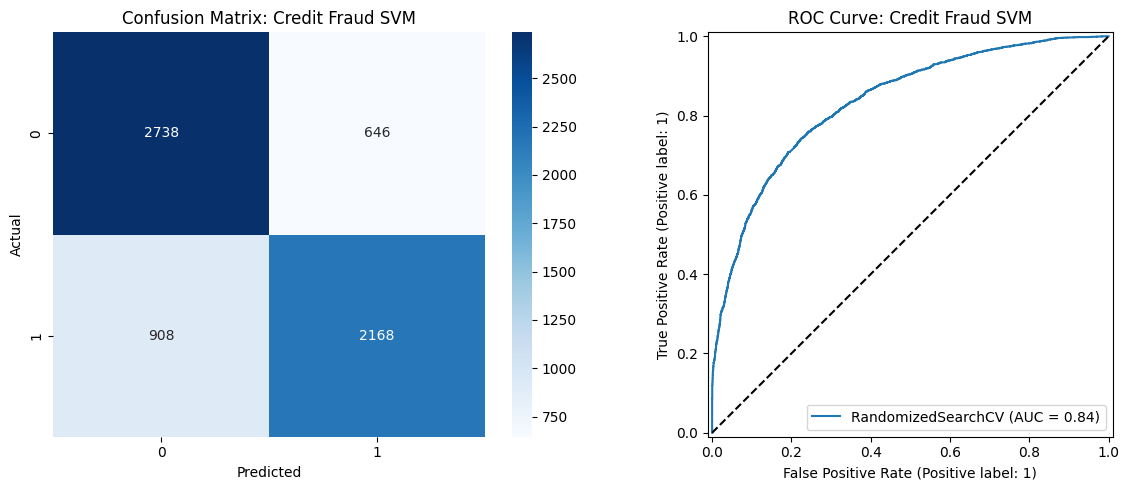


Visualized Heart Disease (KNN)


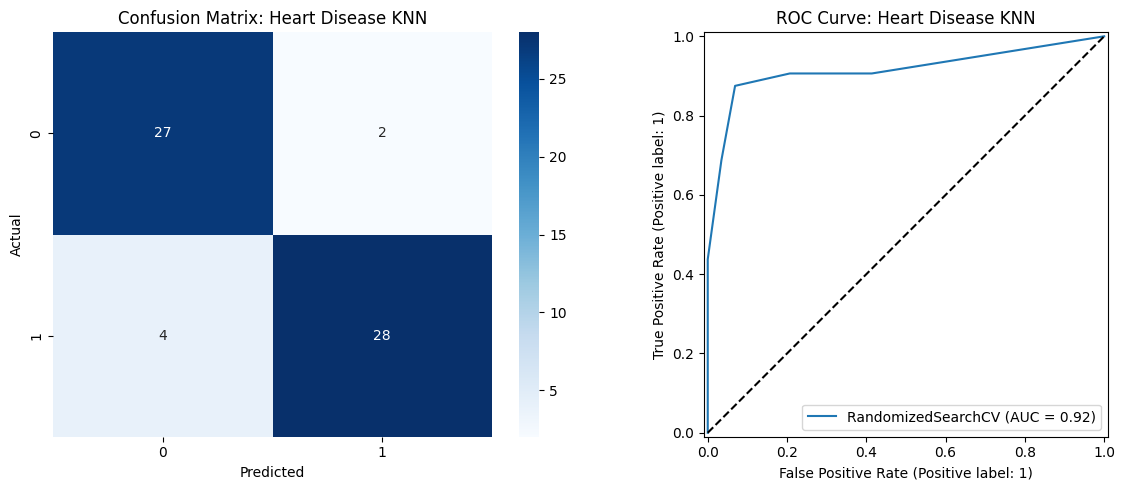

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay

def plot_evaluation(model, X, y, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix: {title}')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X, y, ax=ax[1])
    ax[1].set_title(f'ROC Curve: {title}')
    ax[1].plot([0, 1], [0, 1], 'k--')

    plt.tight_layout()
    plt.show()

print("Visualized Credit Fraud (SVM)")
plot_evaluation(grid_svm_f, X_test, y_test, "Credit Fraud SVM")

print("\nVisualized Heart Disease (KNN)")
plot_evaluation(grid_knn_h, X_test_h, y_test_h, "Heart Disease KNN")

## Evalutation and Previous Work Comparison

### Performance Comparison
- **Credit Fraud:** The optimized SVM achieved an accuracy of about 76% which is slightly higher than the 75.8% reported in Verma's work. However, KNN lagged behind at 71%, suggesting that linear decision boundaries like those used in SVM and Logistic Regression might be more effective for this specific data set than distance-based clustering.
- **Heart Disease:** The models performed significantly better here, with KNN reaching 90% and SVM reaching 87%. The high ROC-AUC values indicate strong class separability, likely due to the clinical nature of the features which are strong physiological indicators. That is to say the features clearly distinguish between healthy and unhealthy patients in this data set.

### Comparison to Previous Work
Verma's logistic regression accuracy of 75.8% and random forest's 75.1% for Credit Fraud are remarkably consistent with the SVM 76%. This suggests a limit to how accurate these models can be made for the current feature set. The "age_err" cleaning logic was vital and was so replicated here.

### Strengths and Limitations
Using pipelines ensured no data leakage during scaling. Hyperparameter tuning improved the Heart Disease KNN model from 87% to 90%.
However it should be noted that the Credit Fraud optimization was performed on a subset of 5,000 samples to ensure runtime stability. Training on the full 32k rows with a non-linear SVM kernel might yield slightly different results but would have taken 40 minutes or so to train.

### Real-World Relevance
In credit fraud a high recall is preferred over precision to catch as many fraudulent transactions as possible, even at the cost of some false alarms. In the Heart Disease data set the 90% accuracy is ok, but in a clinical setting the false negative rate is the most critical metric. The KNN model shows a high precision of 0.93%, but further tuning specifically for recall would be necessary for medical safety.